# Fig S11. estimation bias

In [2]:
from util import fisherztrans,stat_m_e,pair_test,sig,color_inv_alpha,corr_batch_nan
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from faceprf_figure_function import set_figure,set_ax,myviolinplot_ind,myviolinplot_pair,myviolinplot_multi
import pingouin
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

# setting
nsubj = 8
npos = 16
task = ['Digit Task','Face Task']
roi_labels = ['V1','V2','V3','hV4','IOG','pFus','mFus']
nroi = len(roi_labels)
ntask = len(task)

num_nf=[[0,4],[5,9]]
nsample2 = nsubj * np.max(np.diff(num_nf))
nf = ['Near','Far']

trial_nums = [80,160,320,640,1280,2560]


cms=np.array([[255, 195, 73],[145, 115, 185]])/255 # 黄、紫
cms4=['#ed9f98','#8dcc8c','#5ea6db',cms[1]]
cms5=[cms[0],'#ed9f98','#8dcc8c','#5ea6db',cms[1]]
types4 = ['SE','DS',r'SR $\times$ DW',r'Face Task']
types5 = ['Digit Task','SE','DS',r'SR $\times$ DW',r'Face Task']


# data path
data_path = "../data/"



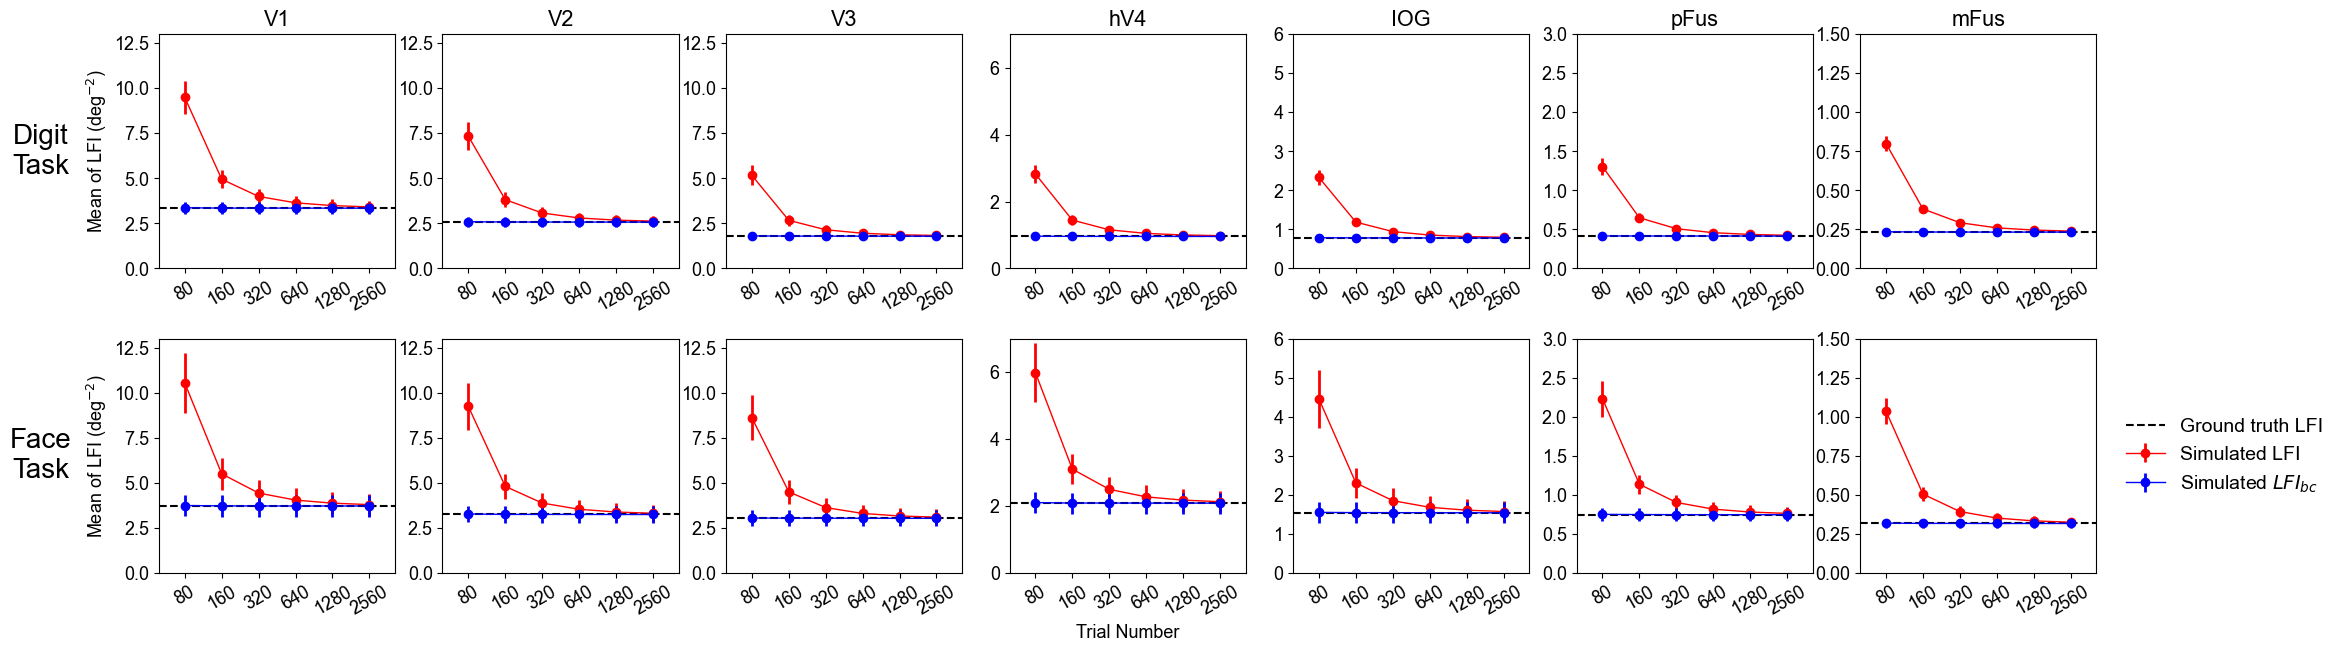

In [3]:
# =========== estimated mean of LFI ===========

task_labels = [f'Digit\nTask',f'Face\nTask']

# far condition
I_d_gt = np.load(data_path+'LFI_bc.npz',allow_pickle=True)['LFI_d_subj'][...,[-1,0]] # d x subj x roi x task
I_subj_gt = np.nanmean(I_d_gt[num_nf[1][0]:num_nf[1][1],:],axis=0) # subj x roi x task

Ibc_subj_sim = []
I_subj_sim = []
for ntrialperposi_sim in trial_nums:
    Ibc_stw_d_subj = np.load(data_path+'trialest_lfi-'+str(ntrialperposi_sim)+'.npz',allow_pickle=True)['Ibc_stw_d_subj'][...,[0,-1]] # nboot x d x subj x roi x task
    Ibc_subj_sim.append(np.nanmean(Ibc_stw_d_subj[:,num_nf[1][0]:num_nf[1][1],:],axis=1))
    I_stw_d_subj = np.load(data_path+'trialest_lfi-'+str(ntrialperposi_sim)+'.npz',allow_pickle=True)['I_stw_d_subj'][...,[0,-1]] # nboot x d x subj x roi x task
    I_subj_sim.append(np.nanmean(I_stw_d_subj[:,num_nf[1][0]:num_nf[1][1],:],axis=1))
Ibc_subj_sim = np.array(Ibc_subj_sim) # trialnum x nboot x subj x roi x task
I_subj_sim = np.array(I_subj_sim) # trialnum x nboot x subj x roi x task

Ibc_subj_sim_m = np.nanmean(Ibc_subj_sim,axis=1)
I_subj_sim_m = np.nanmean(I_subj_sim,axis=1)

set_figure()
plt.rcParams['figure.autolayout'] = False
fig,axes = plt.subplots(ntask,nroi,figsize=(25,7),gridspec_kw={'wspace': 0.2,'hspace':0.3})
ylims = [[0,13],[0,13],[0,13],[0,7],[0,6],[0,3],[0,1.5]]
yticks = [[0,5,10],[0,5,10],[0,5,10],[0,2,4,6],[0,2,4,6],[0,1,2,3],[0,0.5,1,1.5]]
xx = np.arange(0,len(trial_nums))
for task_i in range(ntask):
    for roi_i in range(nroi):
        ax = axes[task_i,roi_i]
        [data_m,data_e,_] = stat_m_e(I_subj_sim_m[:,:,roi_i,task_i].T,'mean','sem')
        ax.errorbar(x=xx,y=data_m,yerr=data_e,marker='o',linewidth=1,color='r',elinewidth=2,label='Simulated LFI')
        [data_m,data_e,_] = stat_m_e(Ibc_subj_sim_m[:,:,roi_i,task_i].T,'mean','sem')
        ax.errorbar(x=xx,y=data_m,yerr=data_e,marker='o',linewidth=1,color='b',elinewidth=2,label='Simulated $LFI_{bc}$')
        ax.axhline(y=np.nanmean(I_subj_gt[:,roi_i,task_i]),linestyle='--',color='k',label='Ground truth LFI')
        ax.set_xticks(xx,trial_nums,rotation=30)
        ax.set_xlim([-0.7,len(trial_nums)-0.3])
        ax.set_ylim(ylims[roi_i])
        #ax.set_yticks(yticks[roi_i])
        axes[0,roi_i].set_title(roi_labels[roi_i])
    axes[task_i,0].set_ylabel('Mean of LFI (deg$^{-2}$)')
    
    axes[task_i,0].text(-0.5,0.5,task_labels[task_i],fontsize=20,transform=axes[task_i,0].transAxes,ha='center',va='center')

axes[1,3].set_xlabel('Trial Number')
axes[-1,-1].legend(loc='center left',bbox_to_anchor=(1.05, 0.5),frameon=False,fontsize=14)


fig.savefig('../figures/figS11-sim_Ibc_m_far.pdf', bbox_inches='tight')


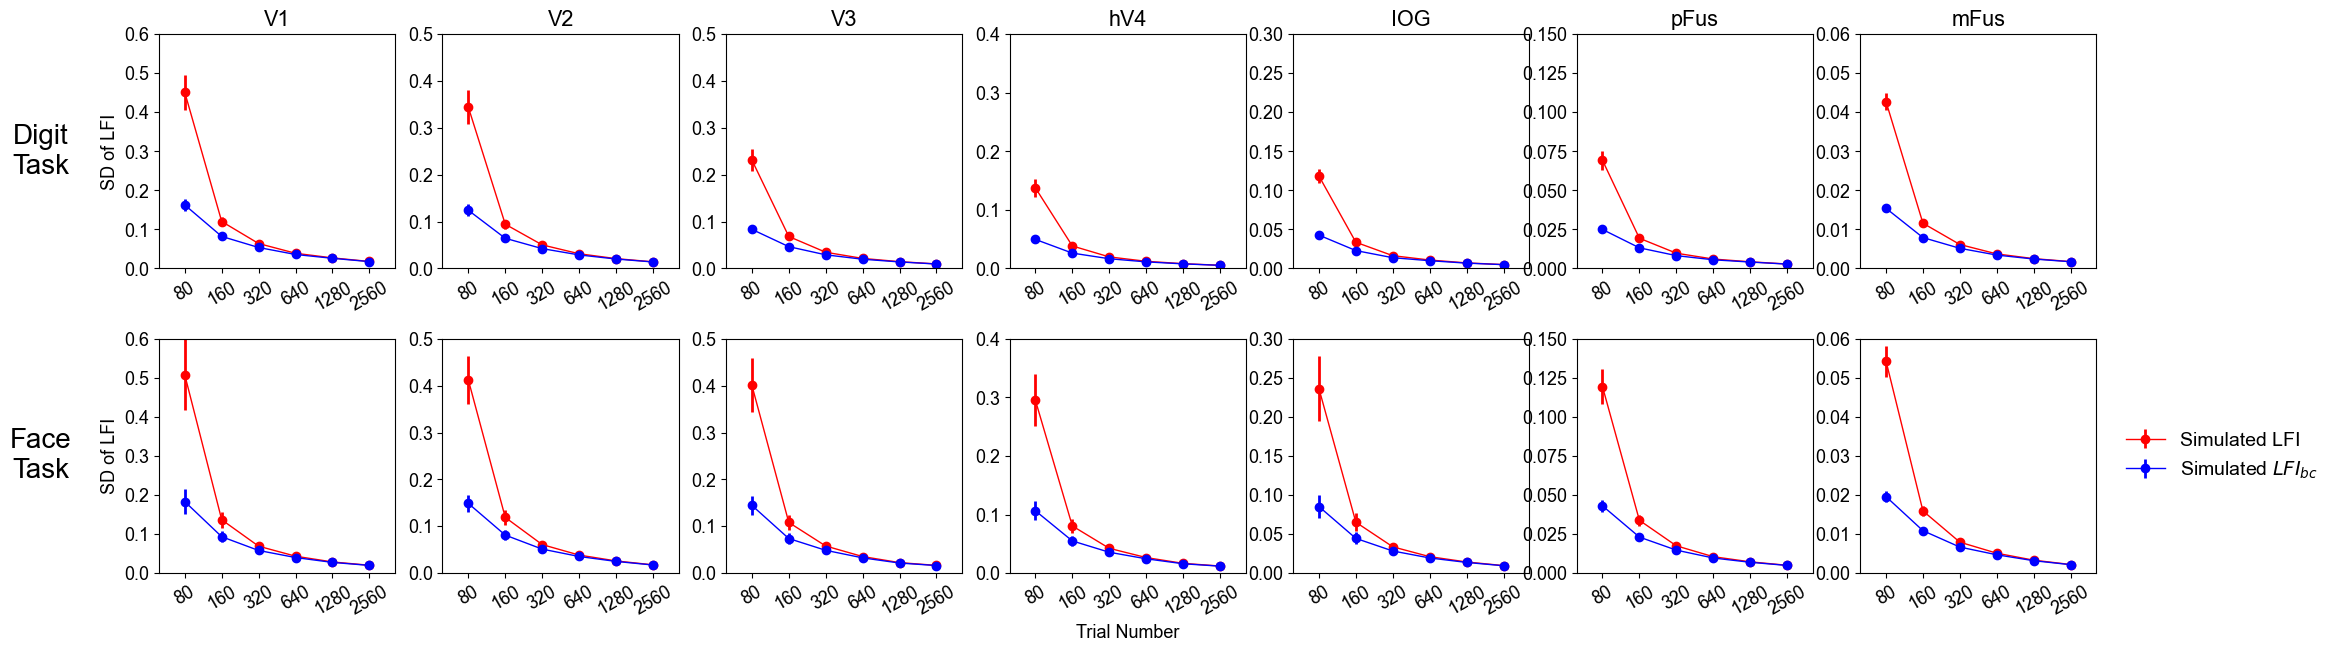

In [4]:
# =========== estimated SD of LFI ===========

task_labels = [f'Digit\nTask',f'Face\nTask']

# far condition

Ibc_subj_sim = []
I_subj_sim = []
for ntrialperposi_sim in trial_nums:
    Ibc_stw_d_subj = np.load(data_path+'trialest_lfi-'+str(ntrialperposi_sim)+'.npz',allow_pickle=True)['Ibc_stw_d_subj'][...,[0,-1]] # nboot x d x subj x roi x task
    Ibc_subj_sim.append(np.nanmean(Ibc_stw_d_subj[:,num_nf[1][0]:num_nf[1][1],:],axis=1))
    I_stw_d_subj = np.load(data_path+'trialest_lfi-'+str(ntrialperposi_sim)+'.npz',allow_pickle=True)['I_stw_d_subj'][...,[0,-1]] # nboot x d x subj x roi x task
    I_subj_sim.append(np.nanmean(I_stw_d_subj[:,num_nf[1][0]:num_nf[1][1],:],axis=1))
Ibc_subj_sim = np.array(Ibc_subj_sim) # trialnum x nboot x subj x roi x task
I_subj_sim = np.array(I_subj_sim) # trialnum x nboot x subj x roi x task

Ibc_subj_sim_sd = np.nanstd(Ibc_subj_sim,axis=1)
I_subj_sim_sd = np.nanstd(I_subj_sim,axis=1)

set_figure()
plt.rcParams['figure.autolayout'] = False
fig,axes = plt.subplots(ntask,nroi,figsize=(25,7),gridspec_kw={'wspace': 0.2,'hspace':0.3})
ylims = [[0,0.6],[0,0.5],[0,0.5],[0,0.4],[0,0.3],[0,0.15],[0,0.06]]
#yticks = [[0,0.2,0.4,0.6],[0,0.2,0.4],[0,0.1,0.2,0.3],[0,0.1,0.2,0.3],[0,0.1,0.2,0.3],[0,0.05,0.1],[0,0.02,0.04]]
xx = np.arange(0,len(trial_nums))
for task_i in range(ntask):
    for roi_i in range(nroi):
        ax = axes[task_i,roi_i]
        [data_m,data_e,_] = stat_m_e(I_subj_sim_sd[:,:,roi_i,task_i].T,'mean','sem')
        ax.errorbar(x=xx,y=data_m,yerr=data_e,marker='o',linewidth=1,color='r',elinewidth=2,label='Simulated LFI')
        [data_m,data_e,_] = stat_m_e(Ibc_subj_sim_sd[:,:,roi_i,task_i].T,'mean','sem')
        ax.errorbar(x=xx,y=data_m,yerr=data_e,marker='o',linewidth=1,color='b',elinewidth=2,label='Simulated $LFI_{bc}$')
        ax.set_xticks(xx,trial_nums,rotation=30)
        ax.set_xlim([-0.7,len(trial_nums)-0.3])
        ax.set_ylim(ylims[roi_i])
        #ax.set_yticks(yticks[roi_i])
        axes[0,roi_i].set_title(roi_labels[roi_i])
    axes[task_i,0].set_ylabel('SD of LFI')
    
    axes[task_i,0].text(-0.5,0.5,task_labels[task_i],fontsize=20,transform=axes[task_i,0].transAxes,ha='center',va='center')

axes[1,3].set_xlabel('Trial Number')
axes[-1,-1].legend(loc='center left',bbox_to_anchor=(1.05, 0.5),frameon=False,fontsize=14)

fig.savefig('../figures/figS11-sim_Ibc_sd_far.pdf', bbox_inches='tight')



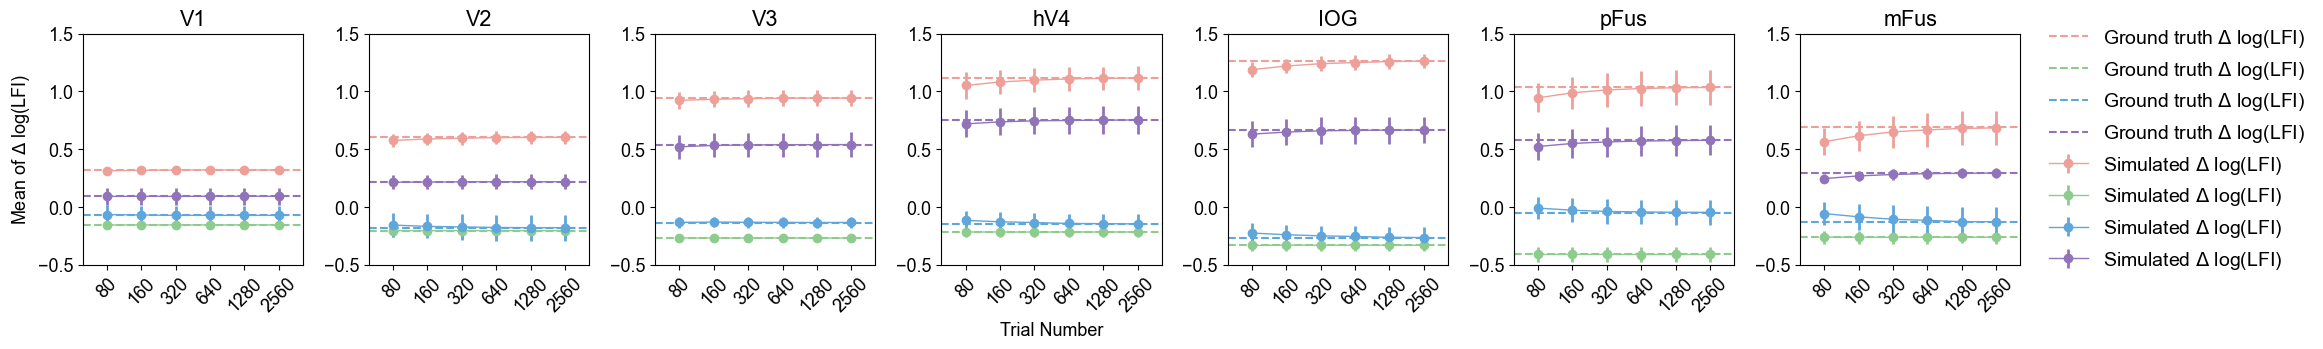

In [5]:
# =========== mean of LFI decomposition terms ===========

# ground-truth: far condition
dI_d_gt = np.load(data_path+'LFI_separate.npz',allow_pickle=True)['deltaIlog_stw_d_subj'] # d x subj x roi x task
dI_subj_gt = np.nanmean(dI_d_gt[num_nf[1][0]:num_nf[1][1],:],axis=0) # subj x roi x task

dI_subj_sim = []
for ntrialperposi_sim in trial_nums:
    dI_stw_d_subj = np.load(data_path+'trialest_lfi-'+str(ntrialperposi_sim)+'.npz',allow_pickle=True)['deltaIlog_stw_d_subj'] # nboot x d x subj x roi x task
    dI_subj_sim.append(np.nanmean(dI_stw_d_subj[:,num_nf[1][0]:num_nf[1][1],:],axis=0))
dI_subj_sim = np.array(dI_subj_sim) # trialnum x nboot x subj x roi x task

dI_subj_sim_m = np.nanmean(dI_subj_sim,axis=1)

set_figure()
plt.rcParams['figure.autolayout'] = False
fig,axes = plt.subplots(1,nroi,figsize=(25,3),gridspec_kw={'wspace': 0.3,'hspace':0.65})
xx = np.arange(0,len(trial_nums))
for mech_i in range(4):
    for roi_i in range(nroi):
        ax = axes[roi_i]
        [data_m,data_e,_] = stat_m_e(dI_subj_sim_m[:,:,roi_i,mech_i].T,'mean','sem')
        ax.errorbar(x=xx,y=data_m,yerr=data_e,marker='o',linewidth=1,color=cms5[mech_i+1],elinewidth=2,label='Simulated $\Delta$ log(LFI)')
        ax.axhline(y=np.nanmean(dI_subj_gt[:,roi_i,mech_i]),linestyle='--',color=cms5[mech_i+1],label='Ground truth $\Delta$ log(LFI)')
        ax.set_xticks(xx,trial_nums,rotation=45)
        ax.set_xlim([-0.7,len(trial_nums)-0.3])
        ax.set_title(roi_labels[roi_i])
        ax.set_ylim([-0.5,1.5])
    
axes[0].set_ylabel('Mean of $\Delta$ log(LFI)')
axes[3].set_xlabel('Trial Number')
axes[-1].legend(loc='center left',bbox_to_anchor=(1.05, 0.5),frameon=False,fontsize=14)

fig.savefig('../figures/figS11-sim_deltaI_m_far.pdf', bbox_inches='tight')



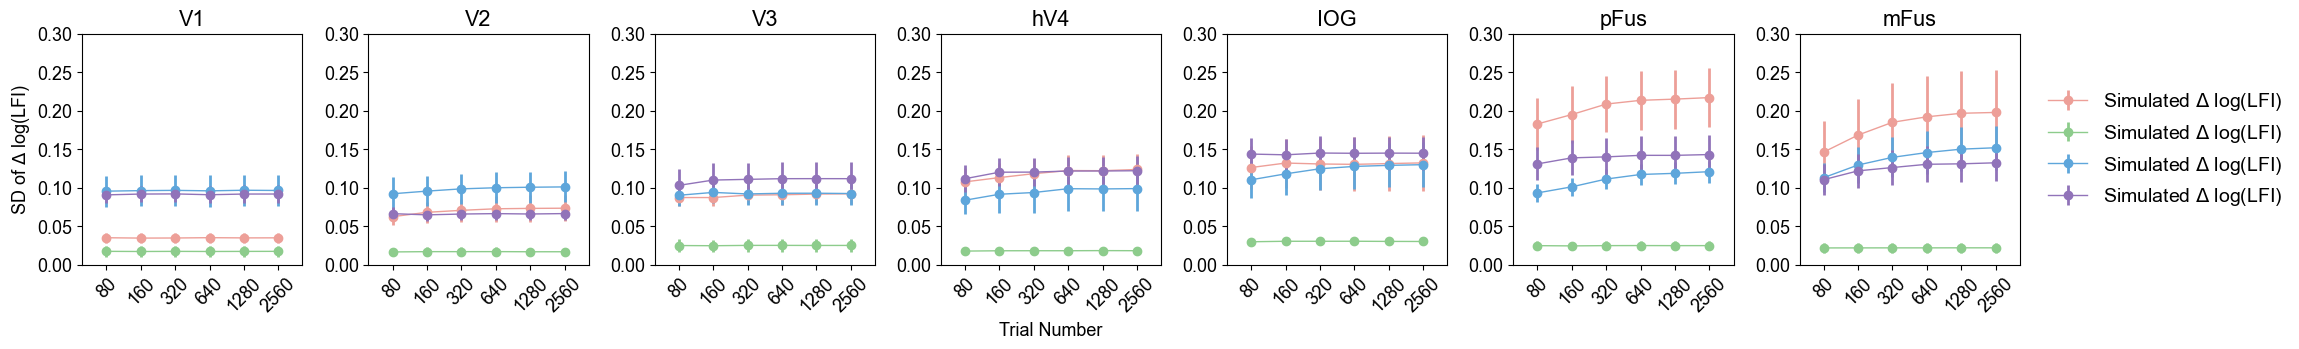

In [6]:
# =========== SD of LFI decomposition terms ===========

# ground-truth: far condition

dI_subj_sim = []
for ntrialperposi_sim in trial_nums:
    dI_stw_d_subj = np.load(data_path+'trialest_lfi-'+str(ntrialperposi_sim)+'.npz',allow_pickle=True)['deltaIlog_stw_d_subj'] # nboot x d x subj x roi x task
    dI_subj_sim.append(np.nanmean(dI_stw_d_subj[:,num_nf[1][0]:num_nf[1][1],:],axis=0))
dI_subj_sim = np.array(dI_subj_sim) # trialnum x nboot x subj x roi x task

dI_subj_sim_sd = np.nanstd(dI_subj_sim,axis=1)

set_figure()
plt.rcParams['figure.autolayout'] = False
fig,axes = plt.subplots(1,nroi,figsize=(25,3),gridspec_kw={'wspace': 0.3,'hspace':0.65})
xx = np.arange(0,len(trial_nums))
for mech_i in range(4):
    for roi_i in range(nroi):
        ax = axes[roi_i]
        [data_m,data_e,_] = stat_m_e(dI_subj_sim_sd[:,:,roi_i,mech_i].T,'mean','sem')
        ax.errorbar(x=xx,y=data_m,yerr=data_e,marker='o',linewidth=1,color=cms5[mech_i+1],elinewidth=2,label='Simulated $\Delta$ log(LFI)')
        ax.set_xticks(xx,trial_nums,rotation=45)
        ax.set_xlim([-0.7,len(trial_nums)-0.3])
        ax.set_title(roi_labels[roi_i])
        ax.set_ylim([0,0.3])
    
axes[0].set_ylabel('SD of $\Delta$ log(LFI)')
axes[3].set_xlabel('Trial Number')
axes[-1].legend(loc='center left',bbox_to_anchor=(1.05, 0.5),frameon=False,fontsize=14)

fig.savefig('../figures/figS11-sim_deltaI_sd_far.pdf', bbox_inches='tight')



V1,Far,[0.0, 0.0, 1.0, 0.2943]
V2,Far,[0.0, 0.0, 0.0946, 0.0001]
V3,Far,[0.0, 0.0, 0.0011, 0.0]
hV4,Far,[0.0, 0.0, 0.5161, 0.0]
IOG,Far,[0.0, 0.0, 0.0008, 0.0]
pFus,Far,[0.0, 0.0, 1.0, 0.0]
mFus,Far,[0.0, 0.0, 1.0, 0.0]


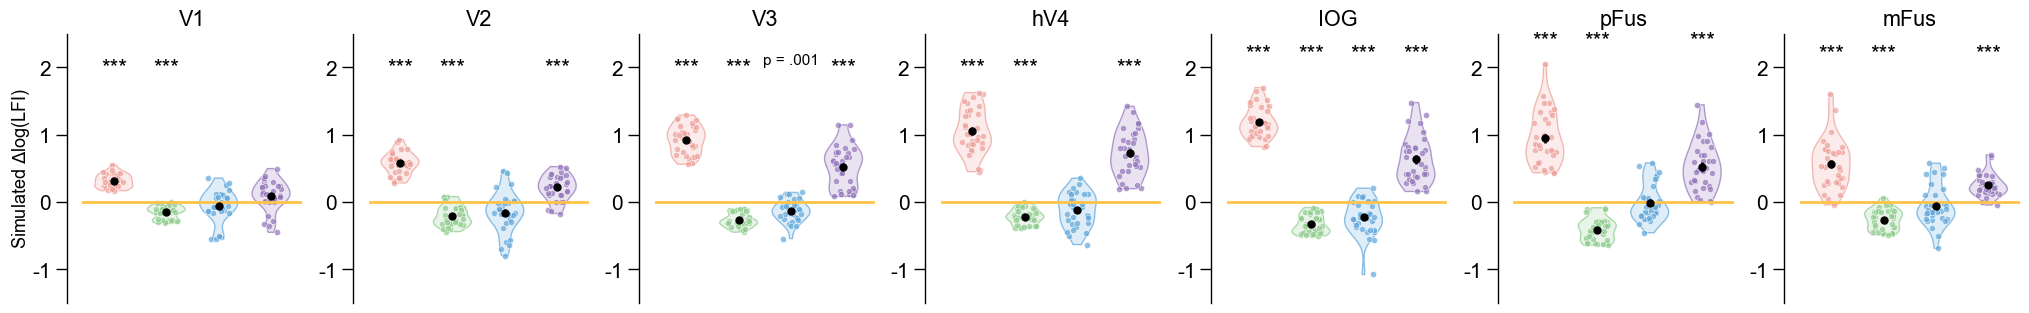

In [9]:
# violin plot: far condition

deltaIlog_stw_d_subj_sim = np.load(data_path+'trialest_lfi-80.npz',allow_pickle=True)['deltaIlog_stw_d_subj']

deltaIlog_stw_subj_nf_sim = np.zeros([nsample2,len(num_nf),len(roi_labels),4])*np.nan # 8subjects*4d x nnf x nroi x 4
for i in range(len(num_nf)):
    for roi_i in range(len(roi_labels)):
        for k in range(4):
            a = np.nanmean(deltaIlog_stw_d_subj_sim[:,num_nf[i][0]:num_nf[i][1],:,roi_i,k],axis=0).flatten()
            deltaIlog_stw_subj_nf_sim[:len(a),i,roi_i,k] = a

ylims = [-1.5,2.5]
ytks = [-1,0,1,2]
pys = [[2],[2],[2],[2],[2.2],[2.4],[2.2]]


set_figure()
plt.rcParams['figure.autolayout'] = False
fig,axes = plt.subplots(1,7,figsize=(25,3.5),gridspec_kw={'wspace': 0.3,'hspace':0.1})
type = ['Digit Task','SE','DS','SR+DW','SS+DS+SR+DW(Face Task)']
ylbls = r'Simulated $\Delta$log(LFI)'

nf_i = 1

# test
ps = np.ones([4,7])
for roi_i in range(len(roi_labels)):
    # Significance
    for j in range(4):
        sts=pingouin.wilcoxon(deltaIlog_stw_subj_nf_sim[:,nf_i,roi_i,j],nan_policy='omit')
        ps[j,roi_i] = sts["p-val"].iloc[0]
ps = multipletests(ps.reshape([28]),method='bonferroni')[1].reshape([4,7])
for roi_i in range(len(roi_labels)):
    print('{},{},{}'.format(roi_labels[roi_i],nf[nf_i],[round(p,4) for p in ps[:,roi_i]]))

# plot
for roi_i in range(len(roi_labels)):
    ax = axes[roi_i]
    set_ax(ax)
    myviolinplot_multi(ax,deltaIlog_stw_subj_nf_sim[:,nf_i,roi_i,:],'mean','sem',ps[:,roi_i],pys[roi_i])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xlim([0.4,4.6])
    ax.set_ylim(ylims)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', width=1, direction='out', length=8, labelsize=15)
    ax.spines['bottom'].set_visible(0)
    ax.spines['left'].set_position(('data', 0.1))     
    ax.axhline(y=0, color=cms[0], linestyle='-',linewidth=2,zorder=2, alpha=1)     # digit 
    if nf_i == 0:
        ax.set_title(roi_labels[roi_i], fontweight="regular",fontsize=18,pad=15)
    for tick in ax.get_yticklabels():
        if tick.get_text() == '0' or tick.get_text() == '0.0':  
            tick.set_color(cms[0])
            tick.set_fontweight('bold')  

    ax.set_yticks(ytks)    
    ax.set_yticklabels(ytks)    
    ax.set_title(roi_labels[roi_i])
axes[0].set_ylabel(ylbls,labelpad=0)

fig.savefig('../figures/figS11-sim_m_separate_far.pdf', bbox_inches='tight')

